In [2]:
import numpy as np
import pandas as pd

In [19]:
df= pd.read_csv('Datasets/Iris.csv')

In [21]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [23]:
df.iloc[:,1:]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [25]:
from sklearn.preprocessing import LabelEncoder

In [27]:
encoder= LabelEncoder()

In [29]:
df= df[df['Species']!= 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
0,3.5,1.4,Iris-setosa
1,3.0,1.4,Iris-setosa
2,3.2,1.3,Iris-setosa
3,3.1,1.5,Iris-setosa
4,3.6,1.4,Iris-setosa


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
df['Species']= encoder.fit_transform(df['Species'])

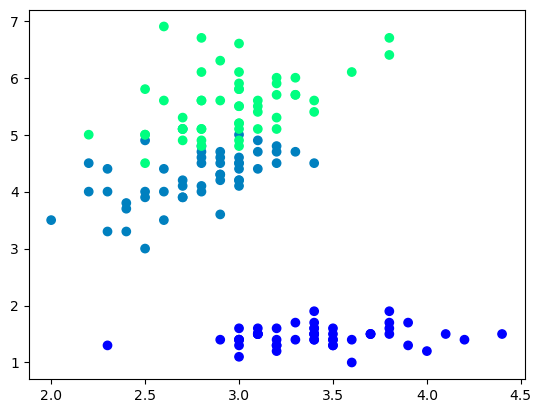

In [39]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c= df['Species'], cmap= 'winter')

In [41]:
df= df.sample(100)
df_train= df.iloc[:60,:].sample(10)
df_val= df.iloc[60:80,:].sample(5)
df_test= df.iloc[80:,:].sample(5)

In [43]:
X_test= df_val.iloc[:,0:2].values
y_test= df_val.iloc[:,-1].values

In [45]:
# Case 1 Bagging

In [47]:
# Data from tree 1

In [49]:
df_bag= df_train.sample(8, replace= True)
X= df_bag.iloc[:, 0:2]
y= df_bag.iloc[:, -1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
32,4.1,1.5,0
24,3.4,1.9,0
31,3.4,1.5,0
22,3.6,1.0,0
38,3.0,1.3,0
38,3.0,1.3,0
38,3.0,1.3,0
86,3.1,4.7,1


In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

In [55]:
dt_bag1= DecisionTreeClassifier()

In [65]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    y_pred= clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))

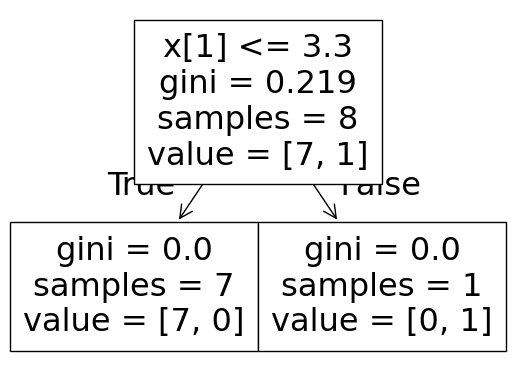

1.0


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [67]:
evaluate(dt_bag1, X, y)

In [69]:
df_bag= df_train.sample(8, replace= True)
X= df_bag.iloc[:, 0:2]
y= df_bag.iloc[:, -1]
df_bag

,SepalWidthCm,PetalLengthCm,Species
86,3.1,4.7,1
75,3.0,4.4,1
31,3.4,1.5,0
24,3.4,1.9,0
32,4.1,1.5,0
62,2.2,4.0,1
75,3.0,4.4,1
38,3.0,1.3,0


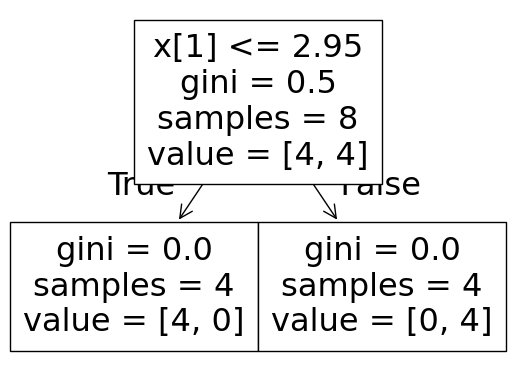

1.0


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [75]:
df_bag2= DecisionTreeClassifier()
evaluate(df_bag2, X, y)

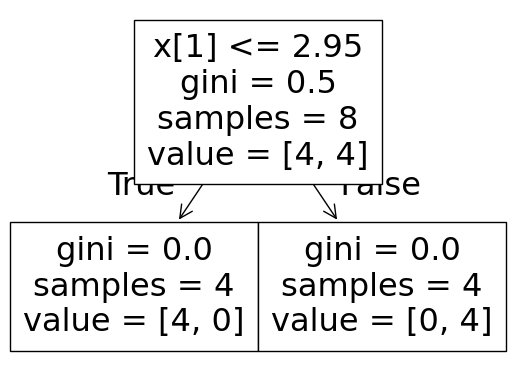

1.0


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [79]:
dt_bag3= DecisionTreeClassifier()
evaluate(dt_bag3, X, y)

In [83]:
print("Predictor 1:", dt_bag1.predict(np.array([3.2, 4.7]).reshape(1, 2)))
print("Predictor 2:", df_bag2.predict(np.array([3.2, 4.7]).reshape(1, 2)))
print("Predictor 3:", dt_bag3.predict(np.array([3.2, 4.7]).reshape(1, 2)))


Predictor 1: [1]
Predictor 2: [1]
Predictor 3: [1]


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [85]:
# Pasting is as same as boosting but here in sampling we do it without replacement